# T1 sweep result (`D:/t1_new`)

Same validity check as `t1_sweep_result.ipynb` (filename vs. timetable-implied dark
time), PLUS a shape diagnostic: a quick look at the `1us` point showed a wide, flat-topped
**positive** pulse (~1us wide) with no clear negative-going dip at all -- a real
departure from the previously-characterized shape (a brief positive AOM transient
followed by a clear negative-going fluorescence dip). Since the positive pulse's
width happened to match that point's own 1us dark time, this checks whether that's a
coincidence (a fixed-duration artifact, e.g. the known AOM transient) or whether the
elevated-region duration actually SCALES with dark time across the sweep -- which
would point at something tracking the dark period itself (electrical pickup
synchronized with it, most likely) rather than genuine NV fluorescence physics.

In [1]:
import os
import re

import numpy as np
import matplotlib.pyplot as plt

from rtb2004 import make_t_from_metadata

DATA_DIR = "D:/t1_new"
POLARIZE_US = 10.0
READOUT_US = 0.3
MISMATCH_TOLERANCE_US = 0.5

## Discover and validate every sweep point (same check as before)

In [2]:
def find_dark_time_files(data_dir):
    pattern = re.compile(r"^(\d+)us\.npy$")
    found = []
    for fname in os.listdir(data_dir):
        m = pattern.match(fname)
        if m:
            found.append((int(m.group(1)), fname[:-4]))
    return sorted(found)


def implied_dark_time_us(data_dir, name):
    timetable_s = np.load(f"{data_dir}/{name}_timetable.npy")
    mean_gap_us = np.diff(timetable_s).mean() * 1e6
    return mean_gap_us - POLARIZE_US - READOUT_US


all_files = find_dark_time_files(DATA_DIR)
valid_files = []
corrupted_files = []
for claimed_us, name in all_files:
    implied_us = implied_dark_time_us(DATA_DIR, name)
    if abs(implied_us - claimed_us) > MISMATCH_TOLERANCE_US:
        corrupted_files.append((claimed_us, name, implied_us))
    else:
        valid_files.append((claimed_us, name))

print(f"found {len(all_files)} points total: {len(valid_files)} valid, "
      f"{len(corrupted_files)} corrupted (filename doesn't match actual timing)")
if corrupted_files:
    for claimed_us, name, implied_us in corrupted_files:
        print(f"  MISMATCH: {name}.npy claims {claimed_us}us, timetable implies {implied_us:.2f}us")

found 218 points total: 218 valid, 0 corrupted (filename doesn't match actual timing)


## Shape diagnostic: elevated-region width vs. labeled dark time

For each valid point, measure the width of the region where the trace sits
significantly ABOVE baseline (the positive artifact/anomaly), and separately check
whether a statistically significant NEGATIVE-going dip (the real fluorescence
signature established previously) exists at all. Only meaningful for dark times
short enough that the whole dark period fits inside the ~4us capture window
(dark_time_us <~ 3.5) -- for longer dark times the window only sees the very start
of the dark period, so the elevated region's full width can't be measured directly,
but whether a negative dip exists is still checked for every point.

In [3]:
THRESHOLD_SIGMA = 5.0

def analyze_shape(data_dir, name):
    waveform = np.load(f"{data_dir}/{name}.npy")
    t_s = make_t_from_metadata(f"{data_dir}/{name}_metadata.txt")
    seg_mean = waveform.mean(axis=0)

    baseline_mask = t_s < -0.1e-6
    baseline = seg_mean[baseline_mask].mean()
    baseline_jitter = seg_mean[baseline_mask].std()
    seg_sem_at_baseline = waveform[:, baseline_mask].std() / np.sqrt(waveform.shape[0])
    threshold = THRESHOLD_SIGMA * seg_sem_at_baseline

    deviation = seg_mean - baseline
    after = np.where(t_s >= 0)[0]

    # positive elevated-region width (first and last crossing above +threshold)
    above = after[deviation[after] > threshold]
    if len(above) > 0:
        elevated_width_us = (t_s[above[-1]] - t_s[above[0]]) * 1e6
        elevated_peak_v = deviation[above].max()
    else:
        elevated_width_us = 0.0
        elevated_peak_v = 0.0

    # real negative-going dip: does one exist at all, 5-sigma significant?
    below = after[deviation[after] < -threshold]
    has_negative_dip = len(below) > 0
    negative_peak_v = deviation[after].min()

    return {
        "elevated_width_us": elevated_width_us,
        "elevated_peak_v": elevated_peak_v,
        "has_negative_dip": has_negative_dip,
        "negative_peak_v": negative_peak_v,
    }


shape_results = []
for dark_time_us, name in valid_files:
    r = analyze_shape(DATA_DIR, name)
    r["dark_time_us"] = dark_time_us
    shape_results.append(r)

n_with_dip = sum(r["has_negative_dip"] for r in shape_results)
print(f"{n_with_dip} of {len(shape_results)} valid points show a statistically "
      f"significant negative-going dip (the real fluorescence signature)")
print(f"{len(shape_results) - n_with_dip} points show NO significant negative dip "
      f"-- likely dominated by the positive anomaly instead")

217 of 218 valid points show a statistically significant negative-going dip (the real fluorescence signature)
1 points show NO significant negative dip -- likely dominated by the positive anomaly instead


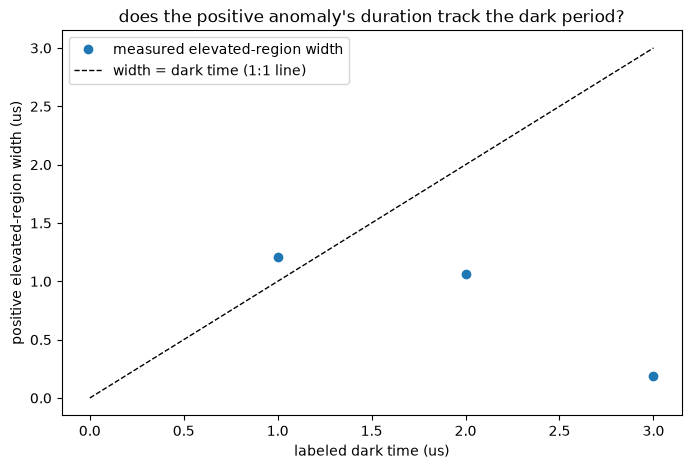

if points fall ON the dashed 1:1 line, the anomaly's duration scales with dark time (points at something synchronized with the dark period itself). If width stays roughly CONSTANT regardless of dark time instead, it's more consistent with a fixed-duration artifact (e.g. the previously-known AOM transient) that just happens to be wider than before.
  dark=1us: elevated width=1.210us
  dark=2us: elevated width=1.062us
  dark=3us: elevated width=0.191us


In [4]:
short_dark_results = [r for r in shape_results if r["dark_time_us"] <= 3.5]
short_dark_times = np.array([r["dark_time_us"] for r in short_dark_results])
short_widths = np.array([r["elevated_width_us"] for r in short_dark_results])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(short_dark_times, short_widths, "o", color="C0", label="measured elevated-region width")
ax.plot([0, short_dark_times.max()], [0, short_dark_times.max()], "k--", lw=1,
        label="width = dark time (1:1 line)")
ax.set_xlabel("labeled dark time (us)")
ax.set_ylabel("positive elevated-region width (us)")
ax.set_title("does the positive anomaly's duration track the dark period?")
ax.legend()
plt.show()

print("if points fall ON the dashed 1:1 line, the anomaly's duration scales with "
      "dark time (points at something synchronized with the dark period itself). "
      "If width stays roughly CONSTANT regardless of dark time instead, it's more "
      "consistent with a fixed-duration artifact (e.g. the previously-known AOM "
      "transient) that just happens to be wider than before.")
for dark_time_us, width_us in zip(short_dark_times, short_widths):
    print(f"  dark={dark_time_us:.0f}us: elevated width={width_us:.3f}us")

## Representative traces across the whole sweep

A handful of dark times spanning the full range, overlaid, to see how (or whether)
the shape changes with dark time.

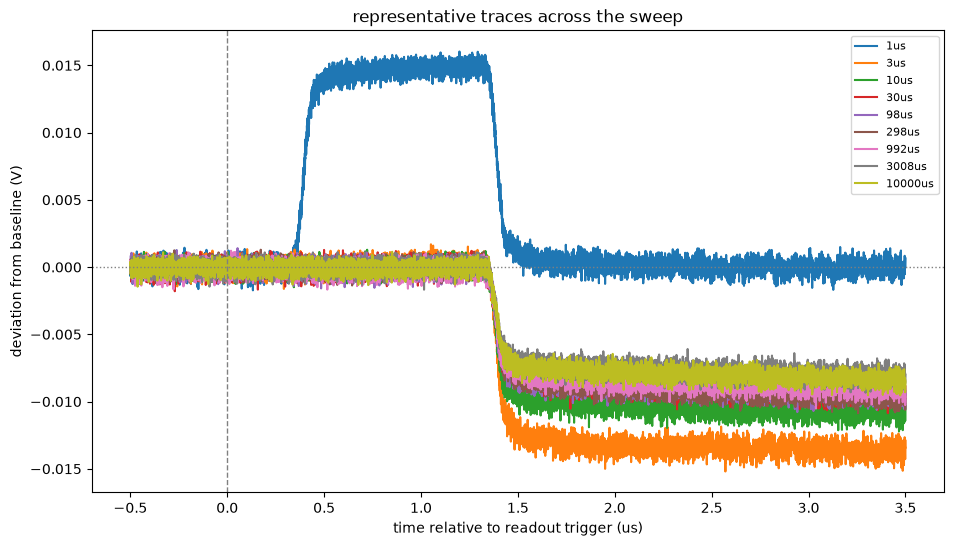

In [5]:
TARGET_DARK_TIMES_US = [1, 3, 10, 30, 100, 300, 1000, 3000, 10000]
valid_dark_times = np.array([dt for dt, _ in valid_files])

fig, ax = plt.subplots(figsize=(11, 6))
for target in TARGET_DARK_TIMES_US:
    idx = np.argmin(np.abs(valid_dark_times - target))
    dark_time_us, name = valid_files[idx]
    waveform = np.load(f"{DATA_DIR}/{name}.npy")
    t_s = make_t_from_metadata(f"{DATA_DIR}/{name}_metadata.txt")
    seg_mean = waveform.mean(axis=0)
    baseline = seg_mean[t_s < -0.1e-6].mean()
    ax.plot(t_s * 1e6, seg_mean - baseline, label=f"{dark_time_us}us")

ax.axhline(0, color="gray", ls=":", lw=1)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("time relative to readout trigger (us)")
ax.set_ylabel("deviation from baseline (V)")
ax.set_title("representative traces across the sweep")
ax.legend(fontsize=8)
plt.show()

## T1 curve using the old methodology (peak negative deviation), for comparison

Same as `t1_sweep_result.ipynb` -- included for direct comparison against the
earlier dataset, but given the shape diagnostic above, points without a significant
negative dip are flagged rather than silently trusted.

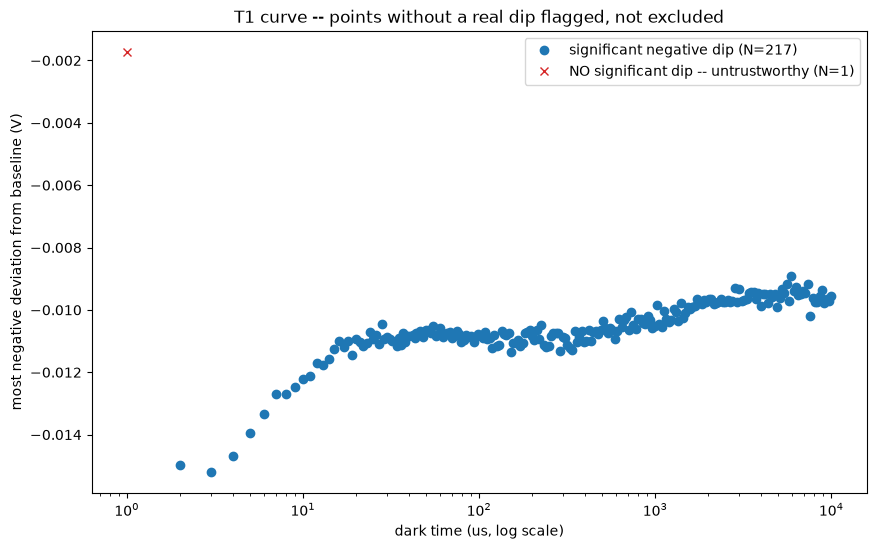

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

dark_times_with_dip = [r["dark_time_us"] for r in shape_results if r["has_negative_dip"]]
peaks_with_dip = [r["negative_peak_v"] for r in shape_results if r["has_negative_dip"]]
dark_times_no_dip = [r["dark_time_us"] for r in shape_results if not r["has_negative_dip"]]
peaks_no_dip = [r["negative_peak_v"] for r in shape_results if not r["has_negative_dip"]]

ax.plot(dark_times_with_dip, peaks_with_dip, "o", color="C0",
        label=f"significant negative dip (N={len(dark_times_with_dip)})")
ax.plot(dark_times_no_dip, peaks_no_dip, "x", color="C3",
        label=f"NO significant dip -- untrustworthy (N={len(dark_times_no_dip)})")
ax.set_xscale("log")
ax.set_xlabel("dark time (us, log scale)")
ax.set_ylabel("most negative deviation from baseline (V)")
ax.set_title("T1 curve -- points without a real dip flagged, not excluded")
ax.legend()
plt.show()